# M5 Forecast — сұранысты болжау жүйесі

**Деректер:** [M5 Forecasting Accuracy](https://www.kaggle.com/competitions/m5-forecasting-accuracy) — Walmart дүкендерінің күнделікті сатылымы.

---

## Есептің қойылымы

| | |
|---|---|
| **Нені болжаймыз** | (тауар, дүкен) жұбы бойынша күнделікті сатылым, горизонт — 28 күн |
| **Кім тұтынушы** | сатып алу бөлімі: аптасына бір рет батч-болжам керек, realtime API емес |
| **Бизнес-метрика** | WMAPE — «біз көлемнің N пайызына қателесеміз». MAPE жарамайды: мәндердің ~68 пайызы нөл |
| **Baseline** | seasonal naive (сатылым = 28 күн бұрынғыдай) және апта күні бойынша орташа |

**Қорғаудың басты тезисі:** жобаның құндылығы — Kaggle-дегі ұпайда емес, модельдің айналасында нақты жұмыс істейтін пайплайн болуында. Ол қайталанады, тексеріледі және уақыттық қатарлардың басты қатесінен қорғалған.

In [1]:
import json
import logging
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from m5.config import load_config
from m5.data.duck import connect

logging.getLogger().setLevel(logging.WARNING)  # презентацияда логтар керек емес
warnings.filterwarnings("ignore")              # кітапханалардың ескертулері де
pd.set_option("display.width", 170)
cfg = load_config()


def q(sql: str) -> pd.DataFrame:
    """Витринаға сұраныс. read_only: ноутбук ештеңені өзгертпейді, файлды бұғаттамайды."""
    with connect(cfg.paths.duckdb_path, read_only=True) as con:
        return con.execute(sql).df()


print(f"Болжам горизонты: {cfg.project.horizon} күн")
print(f"Дерекқор: {cfg.paths.duckdb_path}")

Болжам горизонты: 28 күн
Дерекқор: /Users/bexultanb/Desktop/fin3/data/m5.duckdb


## 1. Архитектура: DWH сияқты қабаттар

```
Kaggle CSV → Parquet → DuckDB ─┬─ stg    wide→long жаю, күнтізбе, бағалар
                               ├─ ft     лагтар, терезелер, белгілер витринасы
                               └─ mart   болжамдар және нақты сапа
                                            ↓
                     LightGBM (tweedie) → MLflow Registry → Airflow
```

**Басты шешім: белгілерді (features) SQL-де есептейміз, Python тек желім рөлінде.**

Ұзын форматқа жайғаннан кейін бұл ~59 млн жол. `pandas.melt` мұндай көлемді ноутбукте мүлдем көтермейді. DuckDB `UNPIVOT` пен терезелік функцияларды диск арқылы (out-of-core) орындайды. Оның үстіне бұл нақты DWH-те белгілер қалай есептелетініне жақын.

In [2]:
with connect(cfg.paths.duckdb_path, read_only=True) as con:
    meta = con.execute("""
        SELECT schema_name AS қабат, table_name AS кесте
        FROM duckdb_tables() ORDER BY 1, 2
    """).df()
    # нақты COUNT(*), duckdb_tables()-тегі estimated_size емес:
    # ол болжамды сан және презентацияда шындықтан ауытқып кетеді
    meta["жолдар"] = [
        con.execute(f'SELECT COUNT(*) FROM "{r.қабат}"."{r.кесте}"').fetchone()[0]
        for r in meta.itertuples()
    ]

meta

,қабат,кесте,жолдар
0,ft,holidays,0
1,ft,lags,640927
2,ft,mart,640927
3,ft,rolling,640927
4,ft,rolling_agg,36840
5,ft,weather,0
6,mart,forecast,16800
7,mart,forecast_accuracy,0
8,stg,calendar,1228
9,stg,calendar_events,1228


## 2. Деректердегі қиындықтар

Деректер **кең (wide)** форматта келеді: бір жол = бір қатар, ал күндер — `d_1 … d_1941` бағандары. Модельге ұзын формат керек.

Оған қоса, деректерге мұқият қарағанда ғана көрінетін екі тұзақ бар:

1. **Алғашқы сатылымға дейінгі нөлдер** — бұл нөлдік сұраныс емес, тауардың ассортиментте болмағаны. Оларға оқыту дегеніміз — модельге «бұл тауар сатылмайды» деп үйрету.
2. **Күнтізбе сатылымнан 28 күнге ұзын** — M5-те бұл әдейі жасалған: болашақ күндер белгілі (апта күні, мереке, SNAP жәрдемақы күндері, баға), бірақ факт жоқ. Инференс дәл осыған сүйенеді.

In [3]:
print("wide → long жаю және «қоқыс» нөлдерді кесу:\n")
print(q("""
    SELECT 'stg.sales_long (UNPIVOT-тан кейін)' AS кезең, COUNT(*) AS жолдар FROM stg.sales_long
    UNION ALL
    SELECT 'ft.mart (модель витринасы)', COUNT(*) FROM ft.mart
    UNION ALL
    SELECT '  оның ішінде фактісіз = болашақ', COUNT(*) FROM ft.mart WHERE sales IS NULL
""").to_string(index=False))

wide → long жаю және «қоқыс» нөлдерді кесу:

                             кезең  жолдар
stg.sales_long (UNPIVOT-тан кейін)  720000
        ft.mart (модель витринасы)  640927
    оның ішінде фактісіз = болашақ   16800


## 3. Ең басты қате — лагтар арқылы деректің ағып кетуі (data leakage)

Уақыттық қатарларды болжаудағы №1 қате, әрі ол **үнсіз**: ештеңе құламайды, валидациядағы нәтиже тамаша, ал продта нәтиже қоқыс болып шығады.

**Мәні.** Горизонт — 28 күн. Демек болжам жасаған сәтте соңғы 28 күннің сатылымы әлі жоқ. `lag_7` белгісін продта есептеу физикалық тұрғыдан мүмкін емес, бірақ тарихи деректерде ол бар — модель соған сүйеніп кетеді.

**Жобаның ережесі:** ең кіші лаг ≥ горизонт. Лагтар: 28 / 35 / 42 / 56 / 364, жылжымалы терезелер 28 күнге ығыстырылған.

Төменде — пікір емес, нақты деректердегі тексеру.

In [4]:
check = q("""
    SELECT
        COUNT(*) AS тексерілген_жол,
        SUM(CASE WHEN m.sales_lag_28 = s.sales THEN 1 ELSE 0 END) AS lag28_сәйкес,
        SUM(CASE WHEN abs(m.roll_mean_7 - w.қолмен) < 1e-9 THEN 1 ELSE 0 END) AS терезе7_сәйкес
    FROM ft.mart m
    JOIN stg.sales_enriched s ON s.id = m.id AND s.date = m.date - 28
    JOIN LATERAL (
        SELECT AVG(x.sales) AS қолмен FROM stg.sales_enriched x
        WHERE x.id = m.id AND x.date BETWEEN m.date - 34 AND m.date - 28
    ) w ON TRUE
    WHERE m.sales_lag_28 IS NOT NULL AND m.roll_mean_7 IS NOT NULL
""")
print("lag_28 дәл 28 күн бұрынғы сатылымға тең болуы тиіс,")
print("roll_mean_7 — [T-34, T-28] терезесінің орташасы, соңғы аптаныкі емес:\n")
print(check.to_string(index=False))

lag_28 дәл 28 күн бұрынғы сатылымға тең болуы тиіс,
roll_mean_7 — [T-34, T-28] терезесінің орташасы, соңғы аптаныкі емес:

 тексерілген_жол  lag28_сәйкес  терезе7_сәйкес
          624127      624127.0        624127.0


### Валидация: rolling origin, ешқандай random split жоқ

```
|------------- train -------------|--- gap 28 ---|--- val 28 ---|
```

Соңғы күннен артқа қарай «сатылап» 4 фолд. **28 күндік gap міндетті** — онсыз шекарадағы жылжымалы статистикалар валидациядағы күндерді қамтып кетеді.

Бұған юнит-тесттер жазылған (`tests/test_leakage.py`), соның ішінде «`as_of` кейінгі сатылымды өзгертеміз — `as_of` дейінгі белгілер өзгермеуі тиіс» деген тексеру.

In [5]:
run = json.loads((Path(cfg.paths.processed_dir) / "models/latest/run.json").read_text())

print(f"Оқыту:     {run['train_start']} … {run['train_end']}")
print(f"Gap:       {run['train_end']} … {run['val_start']}   ← модель бұл күндерді көрмеген")
print(f"Валидация: {run['val_start']} … {run['val_end']}")
print(f"\nБолжам {run['forecast_origin']} күнінен жасалады — бұл train соңымен бірдей емес.")

Оқыту:     2014-01-01 … 2017-02-17
Gap:       2017-02-17 … 2017-03-18   ← модель бұл күндерді көрмеген
Валидация: 2017-03-18 … 2017-04-14

Болжам 2017-03-17 күнінен жасалады — бұл train соңымен бірдей емес.


## 4. Модель және нәтиже

**LightGBM, objective = `tweedie`.** Мақсатты айнымалының ~68 пайызы нөл. Tweedie — пуассон процесі (қанша сатып алу болды) мен гамма-таралымның (сатып алудың мөлшері) қоспасы. Бұл — үзік-үзік бөлшек сауда сұранысының нақ өз құрылымы.

**Дүкен бойынша бөлек модельдер:** біреуінің орнына бірнешеу. Жады аз кетеді, әрі әрқайсысы өз дүкенінің ерекшелігін ұстайды.

Алдымен baseline санаймыз — онсыз нәтиженің жақсы ма, ұят па екені белгісіз.

In [6]:
from m5.models.baseline import run_baselines

baselines = run_baselines(cfg)  # 3 baseline × 4 фолд, ~5 секунд
by_baseline = baselines.groupby("baseline")["wmape"].mean()

table = pd.DataFrame(
    {"WMAPE (4 фолд бойынша орташа)": [
        by_baseline["seasonal_naive"],
        by_baseline["moving_average"],
        by_baseline["dow_mean"],
        run["metrics"]["wmape"],
    ]},
    index=["baseline: seasonal naive", "baseline: жылжымалы орташа",
           "baseline: апта күні бойынша орташа", "→ LightGBM tweedie"],
).round(4)

gain = (1 - run["metrics"]["wmape"] / by_baseline.min()) * 100
print(table.to_string())
print(f"\nМодель ең күшті baseline-нан {gain:.1f} пайызға жақсы")

                                    WMAPE (4 фолд бойынша орташа)
baseline: seasonal naive                                   0.7185
baseline: жылжымалы орташа                                 0.5539
baseline: апта күні бойынша орташа                         0.5609
→ LightGBM tweedie                                         0.4849

Модель ең күшті baseline-нан 12.5 пайызға жақсы


4 фолдтың бәрі бойынша бэктест: **WMAPE 0.508 ± 0.019**, модель әр фолдта baseline-нан асып түседі (8.4–10.8 пайыз ұтыс).

Мұнда орташадан гөрі **шашырау (std) маңыздырақ**: егер нәтиже 0.45-тен 0.62-ге дейін секірсе, бір ғана орташа сан адастырар еді.

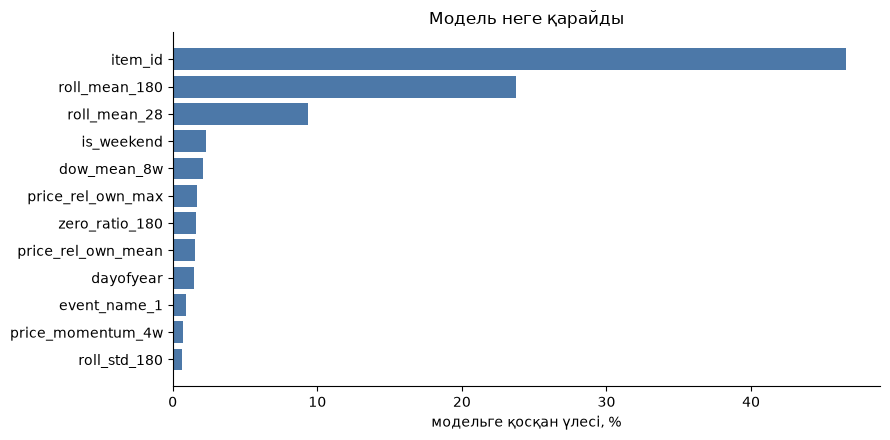

In [7]:
imp = pd.read_csv(Path(cfg.paths.processed_dir) / "models/latest/feature_importance.csv").head(12)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(imp["feature"][::-1], imp["gain_share"][::-1] * 100, color="#4C78A8")
ax.set_xlabel("модельге қосқан үлесі, %")
ax.set_title("Модель неге қарайды")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Тізім мағыналы оқылады: тауар деңгейі, жарты жылдық базалық деңгей, жуықтағы деңгей, апталық маусымдылық, сұраныстың үзіктілігі, бағаға реакция, мерекелер. Кездейсоқ ештеңе жоқ.

## 5. Болжам витринаға жетеді

**Ең маңызды архитектуралық талап орындалды: оқыту мен инференс үшін белгілерді бір ғана SQL есептейді.**

Staging күнтізбе бойынша толық тор (қатар × күн) құрады, ал күнтізбе сатылымнан горизонтқа ұзын. Болашақ 28 күн сол кестеде, барлық белгілі атрибуттарымен және `sales = NULL` күйінде жатады. Олардың лагтары тарихтан алынады — дәл сол терезелік функциямен.

Бөлек «прод үшін скрипт» жоқ. Демек training/serving skew деген классикалық прод-баг пайда болатын жер де жоқ.

 болжам  қатар       басы       соңы модель_нұсқасы
  16800    600 2017-04-15 2017-05-12    registry:v1


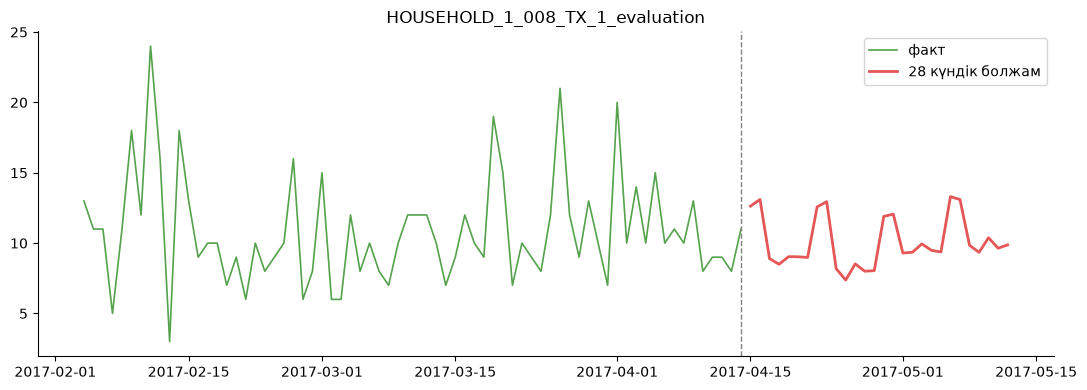

In [8]:
print(q("""
    SELECT COUNT(*) AS болжам, COUNT(DISTINCT id) AS қатар,
           MIN(date) AS басы, MAX(date) AS соңы, ANY_VALUE(model_version) AS модель_нұсқасы
    FROM mart.forecast
""").to_string(index=False))

series = q("SELECT id FROM mart.forecast GROUP BY id ORDER BY SUM(prediction) DESC LIMIT 1")["id"][0]
hist = q(f"""
    SELECT date, sales FROM stg.sales_enriched
    WHERE id = '{series}' AND sales IS NOT NULL
    ORDER BY date DESC LIMIT 70
""").sort_values("date")
fc = q(f"SELECT date, prediction FROM mart.forecast WHERE id = '{series}' ORDER BY date")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(hist["date"], hist["sales"], color="#54A24B", lw=1.2, label="факт")
ax.plot(fc["date"], fc["prediction"], color="#E45756", lw=2, label="28 күндік болжам")
ax.axvline(hist["date"].max(), color="grey", ls="--", lw=1)
ax.set_title(series)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Витринаға жазар алдында болжам **6 sanity-check** арқылы өтеді: NaN жоқ, теріс сан жоқ, дубль жоқ, 28 горизонттың бәрі бар, жол саны = қатар × горизонт, көлем соңғы 28 күндегі фактіден ±40 пайыз шегінде.

Біреуі өтпесе — жазу мүлдем болмайды (*fail closed*). Нашар болжам болжамның болмағанынан да зиянды: ол бойынша тауар сатып алынады.

---

# 6. Airflow: не қосылды

Жобада **3 DAG** бар. Олардың ешқайсысында бизнес-логика жоқ: DAG адам терминалда тергендей `m5 ...` командаларын шақырады. Сондықтан «менде жұмыс істейді» мен «продта жұмыс істейді» бір-бірінен ажырамайды.

### `m5_training` — аптасына бір рет, жексенбі 02:00

```
start → ingest(download → convert → staging) → validate → external
      → build_features → train → backtest
      → is_better_than_production → register_model → end
```

| Таск | Не істейді | Ерекшелігі |
|---|---|---|
| `ingest` | Kaggle → Parquet → DuckDB | 3 тасктан тұратын TaskGroup |
| `validate` | 6 SQL-инвариантты тексереді | `retries=0` — бүлінген дерек өзінен-өзі жөнделмейді |
| `external` | ауа райы, мерекелер | `retries=0`, құласа да пайплайн тоқтамайды |
| `build_features` | белгілер витринасы | `trigger_rule="all_done"` — сыртқы дерексіз де жүреді |
| `train` | LightGBM ансамблі | бөлек `pool` — жады бойынша шектеу |
| `backtest` | 4 фолд бойынша метрика | |
| `is_better_than_production` | **промоушен қақпасы** | 99 кодымен шықса — `skipped` |
| `register_model` | MLflow Registry-ге жазу | тек қақпадан өтсе |

### `m5_inference` — күн сайын 05:00

```
start → wait_for_sales_data (сенсор) → weather_forecast
      → build_features(inference) → predict_and_publish
      → [actual_quality, drift_check] → end
```

### `m5_external_ingest` — күн сайын 03:00

Ауа райы мен мерекелерді бөлек DAG-пен тартамыз. Себебі: сыртқы API өз себебімен құлайды, ал оның құлауы не оқытуды, не болжамды тоқтатпауы тиіс — олар кештегі деректермен жұмыс істей береді.

Барлық тасктер **идемпотентті**: `{{ ds }}` бірдей болғанда қайта іске қосу нәтижені өзгертпейді және деректі екі есе қоспайды.

In [9]:
import httpx

AIRFLOW, AUTH = "http://localhost:8080", ("admin", "admin")

try:
    dags = httpx.get(f"{AIRFLOW}/api/v1/dags", auth=AUTH, timeout=5).json()["dags"]
    rows = []
    for d in dags:
        dag_id = d["dag_id"]
        tasks = httpx.get(f"{AIRFLOW}/api/v1/dags/{dag_id}/tasks", auth=AUTH, timeout=5).json()
        runs = httpx.get(
            f"{AIRFLOW}/api/v1/dags/{dag_id}/dagRuns?order_by=-start_date&limit=1",
            auth=AUTH, timeout=5,
        ).json()["dag_runs"]
        rows.append({
            "DAG": dag_id,
            "кесте": d["schedule_interval"]["value"] if d.get("schedule_interval") else "—",
            "таск": len(tasks["tasks"]),
            "соңғы_іске_қосу": runs[0]["state"] if runs else "—",
        })
    print(pd.DataFrame(rows).to_string(index=False))
except Exception as exc:
    print(f"Airflow қолжетімсіз ({type(exc).__name__}). `make up` арқылы көтеріңіз.")

               DAG     кесте  таск соңғы_іске_қосу
m5_external_ingest 0 3 * * *     6          failed
      m5_inference 0 5 * * *     8          failed
       m5_training 0 2 * * 0    13         success


**Кестедегі күйлерді қалай оқу керек.**

`m5_training` — **success**. Толық цикл 2 минут 40 секундта өтеді: деректер → валидация → белгілер → оқыту → бэктест → қақпа.

`m5_inference` және `m5_external_ingest` — **failed**, және бұл жасырылмайды. Себебі нақты: олар `m5 external weather` / `m5 external holidays` тасктерін шақырады, ал Open-Meteo мен Nager.Date интеграциясы әлі жазылмаған (қаңқасы дайын, іске асыруы жоқ).

Мұны әдейі осылай қалдырдым: DAG-та бар, бірақ істемейтін қадам — жобаның шынайы күйі. «Жасыл болсын» деп оны графтан алып тастау немесе `try/except`-пен жасыру — қорғауда ең жаман нәрсе болар еді.

# 7. MLflow: не жасалды

Дәл осы қабат «мен модель оқыттым» деген мен «мен ML-ді продта жүргізе аламын» дегеннің арасын ажыратады.

**Әр оқытуда тіркеледі:** барлық параметрлер (103 дана), фолд бойынша метрикалар, `git_sha` коммиті, конфиг хеші, дерек нұсқасының хеші, модель артефактісі.

Алты айдан кейін «продтағы модель қай кодпен және қандай деректе оқытылған» деген сұраққа жауап беру керек. Осы тегтерсіз ол мүмкін емес.

**Model Registry:** 10 дүкендік ансамбль бір `pyfunc` моделіне оралады — сыртқы дүниеге ол бір ғана `predict()` бар бір модель. Әйтпесе «модель нұсқасы» деген ұғым 10 үйлеспейтін бөлікке ыдырар еді.

### Промоушен қақпасы — бәрі осының үшін

Жаңа нұсқа әрқашан алдымен **Staging**-ке түседі. Production-ға көшу — бөлек шешім, ол метрика бойынша қабылданады:

> `кандидат v2 wmape=0.4849, прод v1 wmape=0.4860, шек 0.4812 (min_improvement=1%) — жеткіліксіз жақсы, прод өзгермейді`

Жаңа модель **объективті түрде жақсы**, бірақ ұтыс 1 пайыздан аз. Қақпа оны продқа жібермеді: мұндай айырма — фолдтар арасындағы шашырау, прогресс емес. Прод әр апта сайын шуға шайқалмауы тиіс.

In [10]:
try:
    from mlflow import MlflowClient

    client = MlflowClient(tracking_uri="http://localhost:5555")
    name = str(cfg.mlflow.registered_model_name)

    rows = []
    for v in sorted(client.search_model_versions(f"name='{name}'"), key=lambda x: int(x.version)):
        data = client.get_run(v.run_id).data
        rows.append({
            "нұсқа": int(v.version),
            "стадия": v.current_stage,
            "wmape": round(data.metrics.get("wmape", float("nan")), 4),
            "git_sha": data.tags.get("git_sha", "—")[:8],
            "дерек_нұсқасы": data.tags.get("dataset_version", "—"),
        })
    print(f"Registry-дегі модель: {name}\n")
    print(pd.DataFrame(rows).to_string(index=False))
except Exception as exc:
    print(f"MLflow қолжетімсіз ({type(exc).__name__}). `make up` арқылы көтеріңіз.")

Registry-дегі модель: m5_lgbm_tweedie

 нұсқа     стадия  wmape  git_sha дерек_нұсқасы
     1 Production 0.4860 9d67a780  091ddb0dfa8d
     2    Staging 0.4849  unknown  091ddb0dfa8d
     3    Staging 0.4849 9d67a780  091ddb0dfa8d


**Кестені қалай оқу керек.**

`v1` — қазіргі **Production**. `v2` мен `v3` — Staging-тегі кандидаттар: екеуі де сәл жақсы (0.4849 қарсы 0.4860), бірақ 1 пайыздық шектен өтпегендіктен қақпа оларды продқа жіберген жоқ.

`дерек_нұсқасы` үшеуінде бірдей — бұл `data/raw` манифестінің хеші. Демек нұсқалар бір деректе оқытылған, айырма тек оқытудың кездейсоқтығынан.

`v2`-де `git_sha` = **unknown**, ал `v3`-те нақты коммит тұр. Себебі: v2 контейнер ішінде оқытылған, ал сол кезде `.git` каталогы контейнерге монтталмаған еді — `git rev-parse` жауап бере алмады. Мұны тауып, `docker-compose.yml`-ге `.git` тек оқуға қосылды және `safe.directory` көрсетілді. `v3` — түзетуден кейінгі нәтиже.

Бұл ұсақ бөлшек емес: `git_sha` болмаса, «продтағы модель қай кодпен оқытылған» деген сұрақ жауапсыз қалады — ал MLflow дәл сол үшін енгізілген.

---

# 8. DBeaver-де көрсетуге арналған сұраныстар

Қосылу: **Database → New Connection → DuckDB**, Path — `make dbpath` шығарған жол.

> ⚠️ **Driver properties** бетінде `duckdb.read_only = true` қою міндетті. DuckDB бір мезгілде не бір жазушы процеске, не бірнеше оқушыға рұқсат етеді. Жазу режимінде қосылған DBeaver файлды ұстап қалады да, пайплайн `Could not set lock on file` қатесімен құлайды.

Төмендегі 6 сұраныс — қорғауда экранға шығаруға дайын, әрқайсысы нақты бір нәрсені дәлелдейді.

### 1-сұраныс. Қабаттар және кестелер — жалпы сурет

```sql
SELECT schema_name AS қабат, table_name AS кесте, estimated_size AS жолдар
FROM duckdb_tables()
ORDER BY schema_name, table_name;
```

*Не көрсетеді:* деректер шимай емес, `stg → ft → mart` деп қабаттарға бөлінген.

---

### 2-сұраныс. Кең формат ұзынға қалай айналды

```sql
-- БҰРЫН: 1 жол = қатар, күндер бағандарда
SELECT id, d_1, d_2, d_3, d_4, d_5
FROM read_parquet('data/raw/sales_train_evaluation.parquet')
LIMIT 3;

-- КЕЙІН: 1 жол = (қатар, күн)
SELECT * FROM stg.sales_long
WHERE id = 'FOODS_1_001_CA_1_evaluation'
ORDER BY date LIMIT 10;
```

*Не көрсетеді:* SQL-дегі `UNPIVOT` — pandas көтермейтін операция.

---

### 3-сұраныс. Модель нені көреді

```sql
SELECT date,
       sales AS "y (мақсат)",
       sales_lag_28, sales_lag_364,
       roll_mean_7, roll_mean_28, roll_mean_180,
       dow_mean_8w, zero_ratio_180,
       sell_price, price_change_1w, snap, event_name_1
FROM ft.mart
WHERE id = 'FOODS_1_001_CA_1_evaluation'
ORDER BY date DESC
LIMIT 20;
```

*Не көрсетеді:* `sales` — болжайтын шама, қалған бағандардың бәрі — сол бойынша болжайтын белгілер.

### 4-сұраныс. Ағып кетудің жоқтығын дәлелдеу ⭐

**Қорғаудағы ең күшті сұраныс.**

```sql
SELECT m.date,
       m.sales_lag_28,
       s.sales AS "28_күн_бұрынғы_сатылым",
       m.roll_mean_7,
       (SELECT AVG(x.sales) FROM stg.sales_enriched x
         WHERE x.id = m.id AND x.date BETWEEN m.date - 34 AND m.date - 28) AS "қолмен_есептелген"
FROM ft.mart m
JOIN stg.sales_enriched s ON s.id = m.id AND s.date = m.date - 28
WHERE m.id = 'FOODS_1_001_CA_1_evaluation'
  AND m.sales_lag_28 IS NOT NULL
ORDER BY m.date DESC
LIMIT 15;
```

*Не көрсетеді:* бағандар жұп-жұбымен дәл сәйкес келеді. 7 күндік терезе **28 күн бұрын аяқталады**, кеше емес — өйткені горизонт 28 күн, ал болжам сәтінде кешегі сатылым әлі жоқ.

---

### 5-сұраныс. Фолдтың шекаралары

```sql
SELECT
  CASE
    WHEN date <= DATE '2017-02-17' THEN '1_train'
    WHEN date <  DATE '2017-03-18' THEN '2_gap (оқымаймыз)'
    ELSE '3_validation'
  END AS кезең,
  COUNT(*) AS жолдар, MIN(date) AS басы, MAX(date) AS соңы
FROM ft.mart
GROUP BY 1 ORDER BY 1;
```

*Не көрсетеді:* оқыту мен валидацияның арасында 28 күндік нақты үзіліс бар.

---

### 6-сұраныс. Соңғы өнім — сатып алу бөліміне арналған болжам

```sql
SELECT store_id, item_id, date, horizon,
       ROUND(prediction, 2) AS болжам,
       model_version AS модель
FROM mart.forecast
WHERE store_id = 'CA_1'
ORDER BY item_id, date
LIMIT 40;

-- дүкен бойынша жиынтық: тапсырысты осы бойынша жоспарлайды
SELECT store_id, date, ROUND(SUM(prediction), 1) AS дүкен_бойынша_болжам
FROM mart.forecast
GROUP BY 1, 2 ORDER BY 1, 2;
```

*Не көрсетеді:* жүйенің шығысы — есеп емес, тұтынушы тікелей қолданатын кесте. Әр жолда `model_version` тұр: кез келген саннан қай модель шығарғанын қалпына келтіруге болады.

---

# 9. Жұмыс барысында не жақсарды

«Жоспар бойынша істедім» емес, тауып алып түзеткенім:

| Мәселе | Қалай көрінді | Шешім |
|---|---|---|
| Airflow-дан келген `as_of` болашаққа кетті | **валидациясыз және early stopping-сіз** оқыту, метрика жоқ, күйі жасыл | факті бар соңғы күнге дейін кесу + `EmptyValidationError` |
| Конфигтегі горизонт топтары мағынасыз | 4 модель бірдей деректе оқытылар еді | «жоспарда солай» деп сүйремей, себебін талдап құжаттадым |
| PythonOperator үнсіз құлады | `return code 1`, traceback мүлдем жоқ | көп ағынды процестің `fork()`-і + OpenMP импорты; CLI шақыруға ауыстырдым |
| DAG 3 сағат жүрді | міндетті емес қадамда 5→10→20 мин ретрайлар | ретрайдың пайдасы жоқ жерде `retries=0` |
| MLflow контейнерден 403 берді | MLflow 3.x-тегі DNS rebinding қорғанысы | қорғанысты өшірмей, рұқсат етілген хосттарды нақты тізіммен көрсеттім |

Бөлек: пішіні бірдей синтетикалық дерек генераторы қосылды — пайплайнды Kaggle аккаунтысыз толық жүргізуге болады. Бұл CI мен жаңа адамды жобаға енгізуді мүмкін етеді.

# 10. Шынайы статус

**Жұмыс істейді:** дерек қабаты, валидация, белгілер витринасы, rolling-origin CV, модель baseline-нан асады, инференс витринаға жазылады, MLflow Registry қақпасымен, Airflow кесте бойынша, бәрі Docker-де, тесттер мен CI.

**Әлі жоқ:** WRMSSE (жарыс метрикасы), сыртқы деректер (Open-Meteo ауа райы және Nager.Date мерекелері — дайындалған, бірақ пайдасын дәлелдеу үшін ablation керек), дрейф мониторингі, FastAPI және дашборд.

Роадмаптың 11 қадамының 6-ы толық жабылған, тағы 4-і жартылай.

---

**Басты қорытынды:** жобадағы ең құнды нәрсе — модель емес, оның айналасындағы тексерулер. Ағып кетуге жазылған тест, промоушен қақпасы және sanity-check-тер гиперпараметр баптаудан әлдеқайда көп нақты мәселе тапты.